# Evaluación de generalización — Fase 1 (sin peatón)

Evaluación del modelo **E2.1** (mejor de la serie: observación realista, solo LIDAR 5m, 40 dims, sin telemetría de supervisor) en almacenes **no vistos durante el entrenamiento** (WH02-05), comparando los dos generadores de waypoints: **STH-WP** (Spatial Time Horizon) y **SUB-WP** (Subsampling).

**Protocolo:** 3 seeds por método (42, 123, 524) × 4 almacenes × todos los goals de cada almacén, **1 episodio por goal** (sin repeticiones — el simulador es determinista de punta a punta sin peatón: posición inicial fija, política `deterministic=True`, así que repetir un mismo goal reproduce el mismo resultado exacto).

**Total:** 8.136 episodios (2 métodos × 3 seeds × Σgoals(WH02..05), con 172+96+596+492 = 1.356 goals por método/seed).

Cada episodio recorre 3 tramos: **approach** (espera→estantería) → **exit** (estantería→descarga) → **return** (descarga→espera). Resultado categorizado como `exito`, `col_approach`, `col_exit`, `col_return` o `truncado`.

In [1]:
import glob
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams.update({
    "figure.dpi": 150, "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "grid.color": "#D9D9D9", "grid.linestyle": "--", "grid.alpha": 0.55,
})
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 140)

BASE           = Path("/Users/adrigarcia/tfm-robots-rl")
RESULTS_DIR    = BASE / "almacenes" / "resultados_evaluacion"
STHWP_DIR      = BASE / "simulacion" / "controllers" / "rl_train_STHWP"
SUBWP_DIR      = BASE / "simulacion" / "controllers" / "rl_train_SUB_WP_continuo"
BASELINE_DIR_S = STHWP_DIR / "experimentos" / "resultados"
BASELINE_DIR_W = SUBWP_DIR / "experimentos" / "resultados"

RESULTADO_ORDEN = ["exito", "col_approach", "col_exit", "col_return", "truncado"]
RESULTADO_COLOR = {
    "exito":        "#2ca02c",
    "col_approach": "#d62728",
    "col_exit":     "#ff7f0e",
    "col_return":   "#9467bd",
    "truncado":     "#7f7f7f",
}
METODO_ORDEN = ["sthwp", "subwp"]
METODO_LABEL = {"sthwp": "STH-WP", "subwp": "SUB-WP"}
METODO_COLOR = {"sthwp": "#1F77B4", "subwp": "#FF7F0E"}
sns.set_palette([METODO_COLOR[m] for m in METODO_ORDEN])
WH_ORDEN     = ["02", "03", "04", "05"]

IMG_DIR = BASE / "almacenes" / "imagenes_evaluacion" / "fase1_sin_peaton"
IMG_DIR.mkdir(parents=True, exist_ok=True)

def guardar(fig, nombre):
    fig.savefig(IMG_DIR / f"{nombre}.png", dpi=150, bbox_inches="tight")


## 1. Carga de datos

In [2]:
def cargar_fase1():
    frames = []
    for fn in sorted(glob.glob(str(RESULTS_DIR / "*_wh*_s*.csv"))):
        if "_ped_" in fn:
            continue
        df = pd.read_csv(fn)
        frames.append(df)
    df = pd.concat(frames, ignore_index=True)
    df["warehouse_id"] = df["warehouse_id"].astype(str).str.zfill(2)
    df["seed"] = df["seed"].astype(str)
    df["exito_bool"] = df["resultado"] == "exito"
    df["resultado"] = pd.Categorical(df["resultado"], categories=RESULTADO_ORDEN, ordered=True)
    df["metodo"] = pd.Categorical(df["metodo"], categories=METODO_ORDEN, ordered=True)
    return df

df1 = cargar_fase1()
print(f"Total episodios cargados: {len(df1)}")
df1.head()


Total episodios cargados: 8136


,episodio,goal_id,resultado,pasos,reward,warehouse_id,metodo,seed,exito_bool
0,1,goal_001,exito,5808,1041.80,02,sthwp,123,True
1,2,goal_002,exito,5750,1045.54,02,sthwp,123,True
2,3,goal_003,exito,5693,1050.82,02,sthwp,123,True
3,4,goal_004,exito,5618,1041.49,02,sthwp,123,True
4,5,goal_005,exito,5593,1041.27,02,sthwp,123,True


### Comprobación de completitud
Cuántos episodios hay por combinación almacén × método × seed (debería coincidir con el nº de goals de cada almacén).

In [3]:
tabla_completitud = (
    df1.groupby(["warehouse_id", "metodo", "seed"], observed=True)
    .size()
    .unstack("seed")
    .reindex(WH_ORDEN, level="warehouse_id")
)
tabla_completitud


seed                 123   42  524
warehouse_id metodo               
02           sthwp   172  172  172
             subwp   172  172  172
03           sthwp    96   96   96
             subwp    96   96   96
04           sthwp   596  596  596
             subwp   596  596  596
05           sthwp   492  492  492
             subwp   492  492  492

## 2. Resumen global

In [4]:
resumen_global = (
    df1.groupby("metodo", observed=True)["exito_bool"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "tasa_exito", "count": "n_episodios"})
)
resumen_global["tasa_exito_%"] = (resumen_global["tasa_exito"] * 100).round(2)
resumen_global = resumen_global.rename(index=METODO_LABEL)
resumen_global[["n_episodios", "tasa_exito_%"]]


,n_episodios,tasa_exito_%
metodo,,
STH-WP,4068,98.97
SUB-WP,4068,100.00


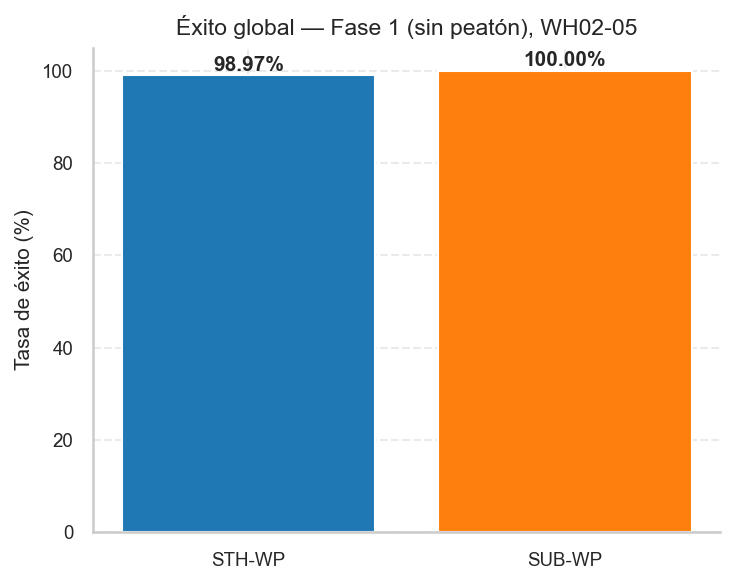

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
vals = resumen_global["tasa_exito_%"]
bars = ax.bar(vals.index, vals.values, color=["#1f77b4", "#ff7f0e"])
ax.set_ylabel("Tasa de éxito (%)")
ax.set_ylim(0, 105)
ax.set_title("Éxito global — Fase 1 (sin peatón), WH02-05")
for b, v in zip(bars, vals.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.2f}%", ha="center", fontweight="bold")
plt.tight_layout()
guardar(fig, "01_exito_global")
plt.show()


## 3. Resultados por almacén

In [6]:
pivot_wh_metodo = (
    df1.groupby(["warehouse_id", "metodo"], observed=True)["exito_bool"]
    .mean().mul(100).round(2)
    .unstack("metodo")
    .reindex(WH_ORDEN)
    .rename(columns=METODO_LABEL)
)
pivot_wh_metodo.index = ["WH" + w for w in pivot_wh_metodo.index]
pivot_wh_metodo


metodo,STH-WP,SUB-WP
WH02,96.90,100.0
WH03,100.00,100.0
WH04,99.78,100.0
WH05,98.51,100.0


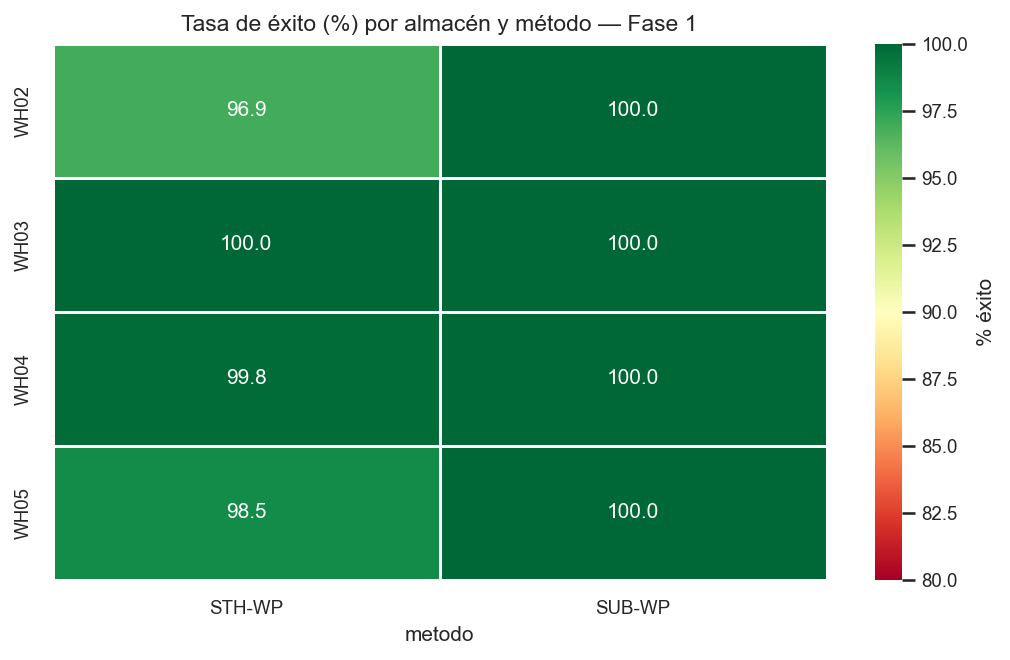

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(pivot_wh_metodo, annot=True, fmt=".1f", cmap="RdYlGn", vmin=80, vmax=100,
            cbar_kws={"label": "% éxito"}, ax=ax, linewidths=0.5)
ax.set_title("Tasa de éxito (%) por almacén y método — Fase 1")
plt.tight_layout()
guardar(fig, "02_heatmap_almacen_metodo")
plt.show()


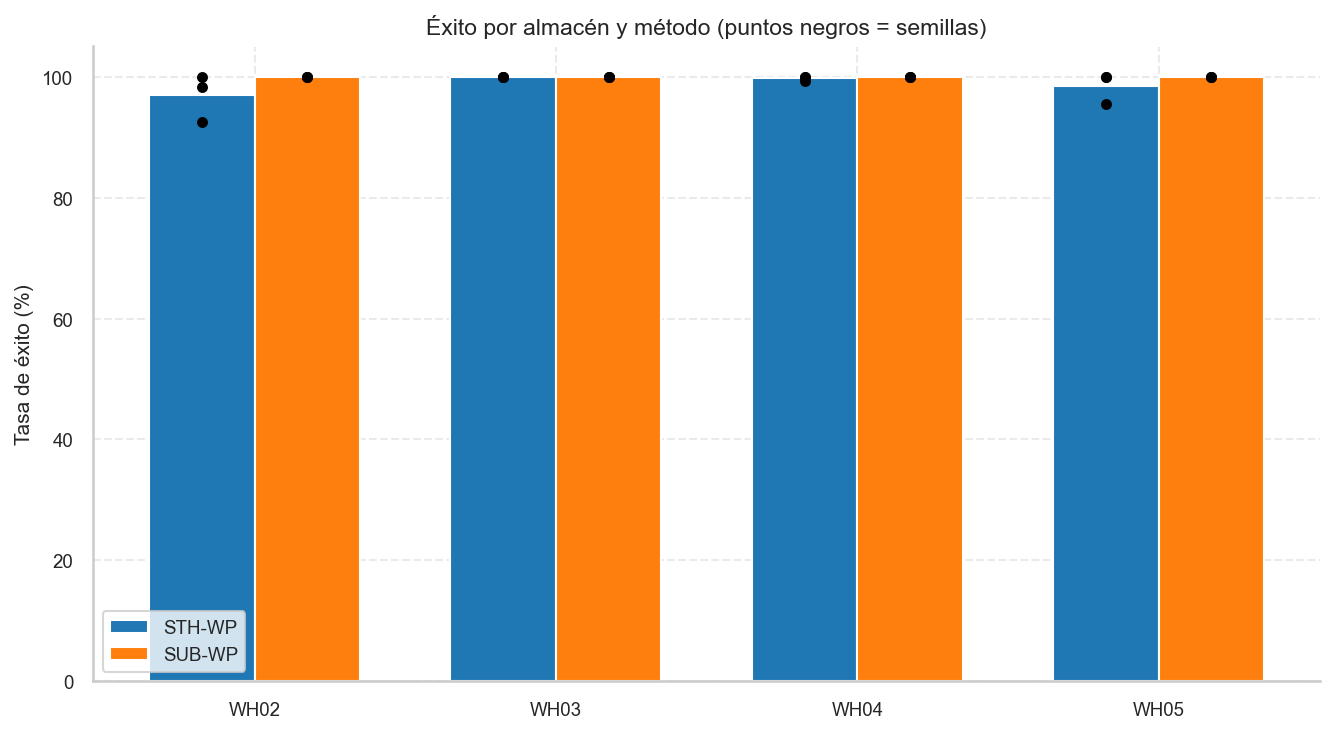

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(WH_ORDEN))
width = 0.35
for i, metodo in enumerate(METODO_ORDEN):
    sub = df1[df1["metodo"] == metodo]
    medias = sub.groupby("warehouse_id", observed=True)["exito_bool"].mean().mul(100).reindex(WH_ORDEN)
    ax.bar(x + (i - 0.5) * width, medias.values, width, label=METODO_LABEL[metodo])
    # puntos individuales por seed
    for seed in sub["seed"].unique():
        sub_seed = sub[sub["seed"] == seed]
        vals = sub_seed.groupby("warehouse_id", observed=True)["exito_bool"].mean().mul(100).reindex(WH_ORDEN)
        ax.scatter(x + (i - 0.5) * width, vals.values, color="black", s=18, zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(["WH" + w for w in WH_ORDEN])
ax.set_ylabel("Tasa de éxito (%)")
ax.set_ylim(0, 105)
ax.set_title("Éxito por almacén y método (puntos negros = semillas)")
ax.legend()
plt.tight_layout()
guardar(fig, "03_exito_por_almacen_seeds")
plt.show()


### Variabilidad entre seeds

In [9]:
variab_seed = (
    df1.groupby(["metodo", "warehouse_id", "seed"], observed=True)["exito_bool"]
    .mean().mul(100).round(2)
    .unstack("seed")
    .reindex(WH_ORDEN, level="warehouse_id")
)
variab_seed["rango_max_min"] = (variab_seed.max(axis=1) - variab_seed.min(axis=1)).round(2)
variab_seed


seed                    123     42     524  rango_max_min
metodo warehouse_id                                      
sthwp  02             92.44  100.0   98.26           7.56
       03            100.00  100.0  100.00           0.00
       04            100.00  100.0   99.33           0.67
       05            100.00  100.0   95.53           4.47
subwp  02            100.00  100.0  100.00           0.00
       03            100.00  100.0  100.00           0.00
       04            100.00  100.0  100.00           0.00
       05            100.00  100.0  100.00           0.00

## 4. Comparación con el baseline de entrenamiento (WH01)
Baseline real de E2.1 en el almacén de entrenamiento, **sin peatón** (cargado directamente de los CSV de inferencia, no de memoria).

In [10]:
def cargar_baseline_wh01_noped():
    filas = []
    for metodo, carpeta in [("sthwp", BASELINE_DIR_S), ("subwp", BASELINE_DIR_W)]:
        for fn in sorted(glob.glob(str(carpeta / f"{metodo}_infer_e2_1_noped_s*.csv"))):
            d = pd.read_csv(fn)
            d["metodo"] = metodo
            filas.append(d)
    d = pd.concat(filas, ignore_index=True)
    d["exito_bool"] = d["resultado"] == "exito"
    return d

baseline_wh01 = cargar_baseline_wh01_noped()
resumen_wh01 = baseline_wh01.groupby("metodo")["exito_bool"].mean().mul(100).round(2)
resumen_wh01


/var/folders/f5/mfsbgdz157x618_ct5hj62g00000gn/T/ipykernel_19293/1119059198.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  d = pd.concat(filas, ignore_index=True)


metodo
sthwp    100.0
subwp    100.0
Name: exito_bool, dtype: float64

In [11]:
comparacion_gap = pd.DataFrame({
    "WH01 (entrenamiento, sin peatón)": resumen_wh01,
    "WH02-05 (generalización, media)": df1.groupby("metodo", observed=True)["exito_bool"].mean().mul(100).round(2),
})
comparacion_gap.index = [METODO_LABEL[m] for m in comparacion_gap.index]
comparacion_gap["gap_generalizacion_pp"] = (comparacion_gap["WH01 (entrenamiento, sin peatón)"]
                                             - comparacion_gap["WH02-05 (generalización, media)"]).round(2)
comparacion_gap


,"WH01 (entrenamiento, sin peatón)","WH02-05 (generalización, media)",gap_generalizacion_pp
STH-WP,100.0,98.97,1.03
SUB-WP,100.0,100.00,0.00


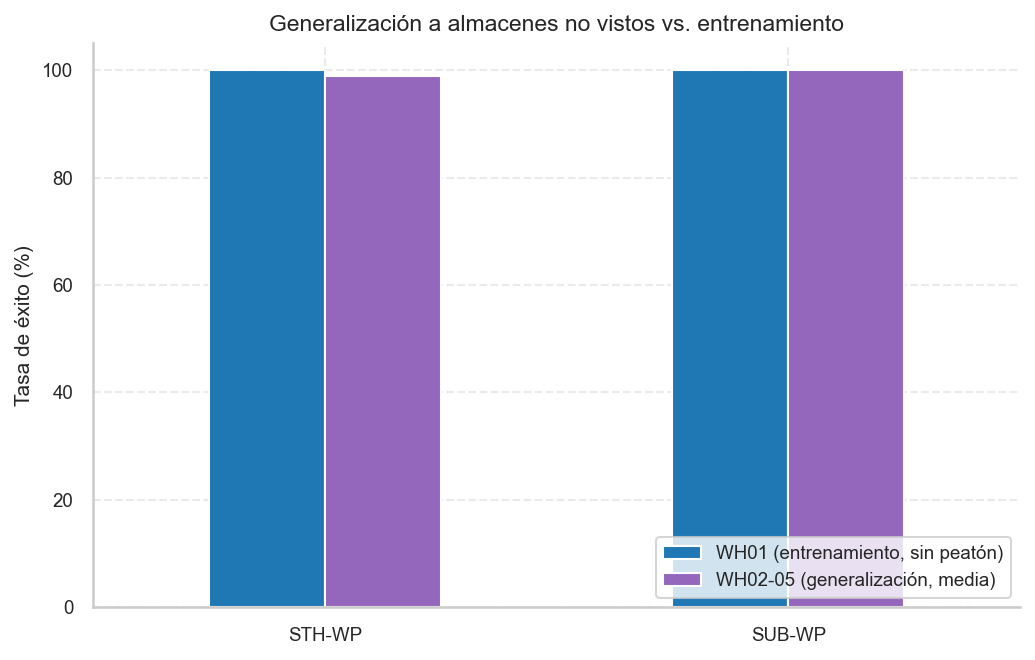

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
comparacion_gap[["WH01 (entrenamiento, sin peatón)", "WH02-05 (generalización, media)"]].plot(
    kind="bar", ax=ax, color=["#1F77B4", "#9467BD"], rot=0)
ax.set_ylabel("Tasa de éxito (%)")
ax.set_ylim(0, 105)
ax.set_title("Generalización a almacenes no vistos vs. entrenamiento")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
guardar(fig, "04_comparacion_baseline_wh01")
plt.show()


## 5. Desglose de fallos

In [13]:
desglose = (
    df1.groupby(["warehouse_id", "metodo", "resultado"], observed=False)
    .size().unstack("resultado").fillna(0).astype(int)
    .reindex(WH_ORDEN, level="warehouse_id")
)
desglose_pct = desglose.div(desglose.sum(axis=1), axis=0).mul(100).round(2)
desglose


resultado            exito  col_approach  col_exit  col_return  truncado
warehouse_id metodo                                                     
02           sthwp     500             2        14           0         0
             subwp     516             0         0           0         0
03           sthwp     288             0         0           0         0
             subwp     288             0         0           0         0
04           sthwp    1784             2         2           0         0
             subwp    1788             0         0           0         0
05           sthwp    1454             0        22           0         0
             subwp    1476             0         0           0         0

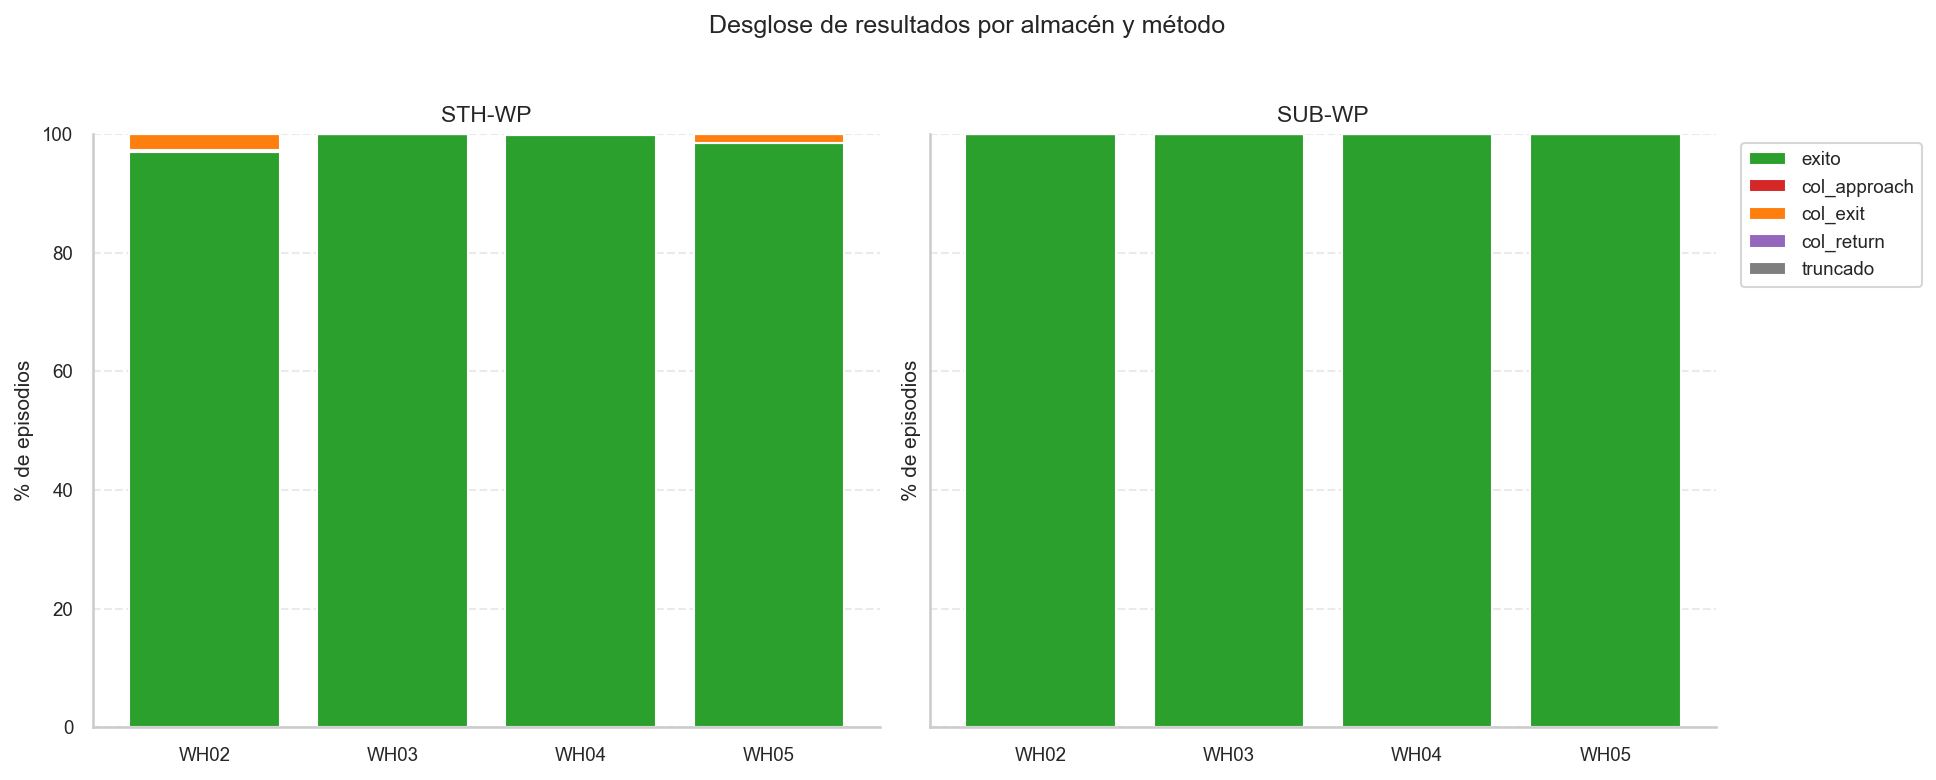

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, metodo in zip(axes, METODO_ORDEN):
    sub = desglose_pct.xs(metodo, level="metodo")
    sub = sub.reindex(WH_ORDEN)
    bottom = np.zeros(len(sub))
    for resultado in RESULTADO_ORDEN:
        if resultado not in sub.columns:
            continue
        vals = sub[resultado].values
        ax.bar(["WH" + w for w in sub.index], vals, bottom=bottom,
               label=resultado, color=RESULTADO_COLOR[resultado])
        bottom += vals
    ax.set_title(METODO_LABEL[metodo])
    ax.set_ylabel("% de episodios")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Desglose de resultados por almacén y método", y=1.03)
plt.tight_layout()
guardar(fig, "05_desglose_fallos")
plt.show()


### Distribución de los tipos de fallo (sin el éxito)
El gráfico anterior diluye los tipos de fallo porque el éxito domina la barra (96-100%). Aquí se recalculan los porcentajes **solo entre los episodios fallidos** de cada almacén/método (suman 100%), para comparar mejor qué tipo de colisión predomina.

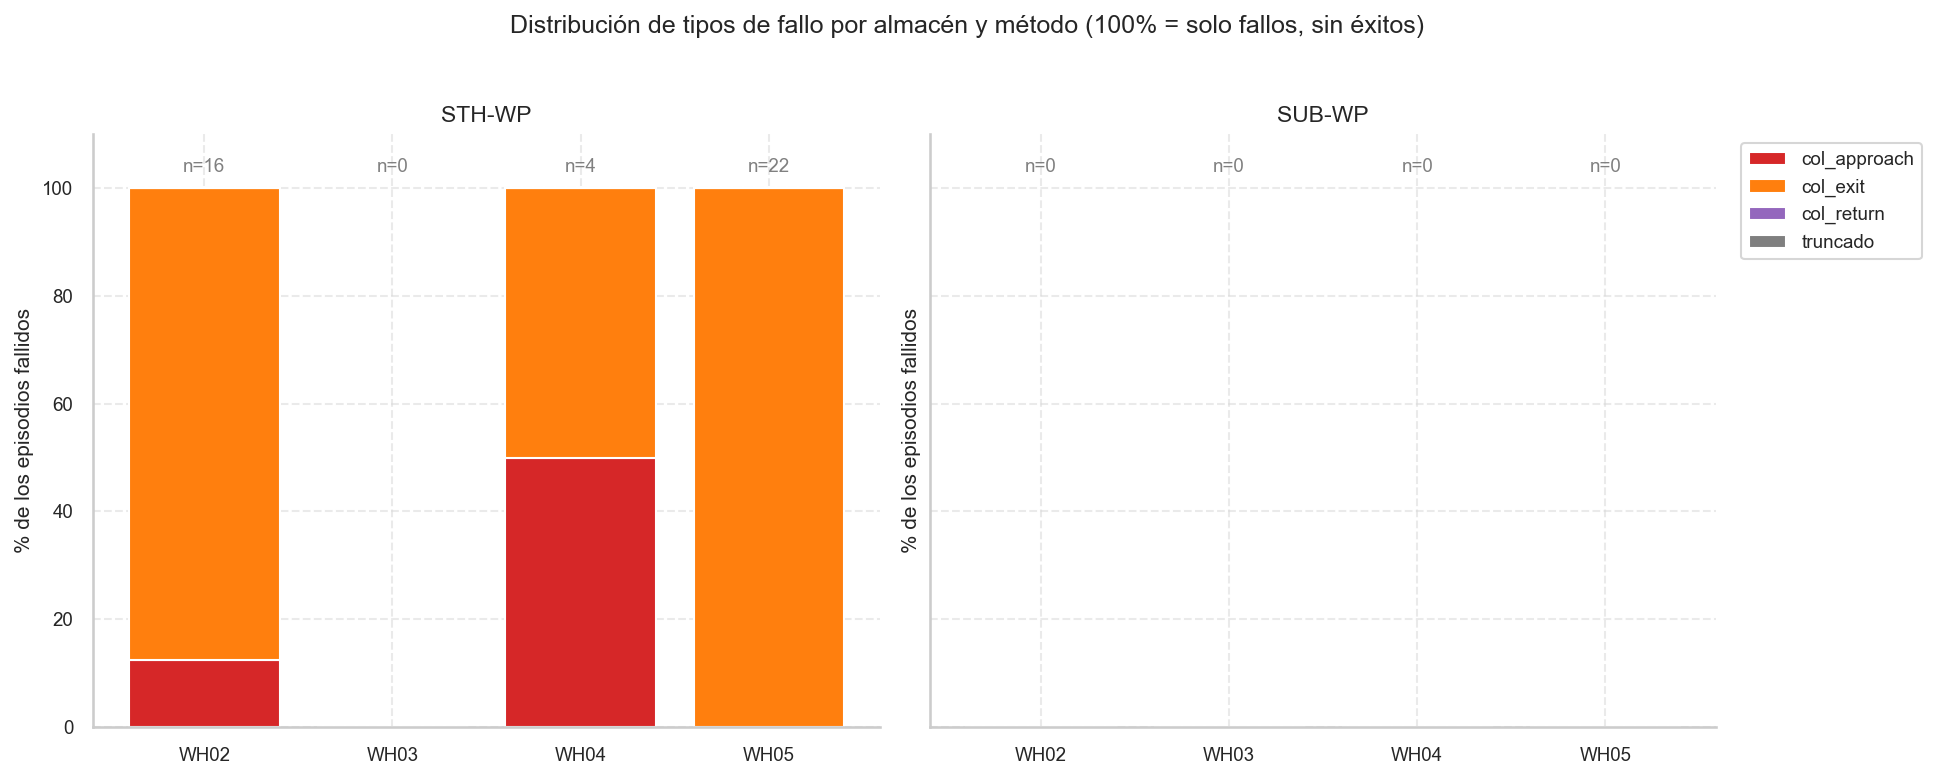

In [15]:
fallo_cols = [r for r in RESULTADO_ORDEN if r != "exito" and r in desglose.columns]
n_fallos_totales = desglose[fallo_cols].sum(axis=1)
desglose_fallos_pct = desglose[fallo_cols].div(n_fallos_totales, axis=0).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, metodo in zip(axes, METODO_ORDEN):
    sub = desglose_fallos_pct.xs(metodo, level="metodo").reindex(WH_ORDEN)
    n_sub = n_fallos_totales.xs(metodo, level="metodo").reindex(WH_ORDEN)
    bottom = np.zeros(len(sub))
    for resultado in fallo_cols:
        vals = sub[resultado].fillna(0).values
        ax.bar(["WH" + w for w in sub.index], vals, bottom=bottom,
               label=resultado, color=RESULTADO_COLOR[resultado])
        bottom += vals
    for x, n in enumerate(n_sub.values):
        ax.text(x, 103, f"n={int(n)}", ha="center", fontsize=9, color="gray")
    ax.set_title(METODO_LABEL[metodo])
    ax.set_ylabel("% de los episodios fallidos")
    ax.set_ylim(0, 110)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Distribución de tipos de fallo por almacén y método (100% = solo fallos, sin éxitos)", y=1.03)
plt.tight_layout()
guardar(fig, "05b_distribucion_tipos_fallo")
plt.show()


## 6. Distribución de pasos y reward

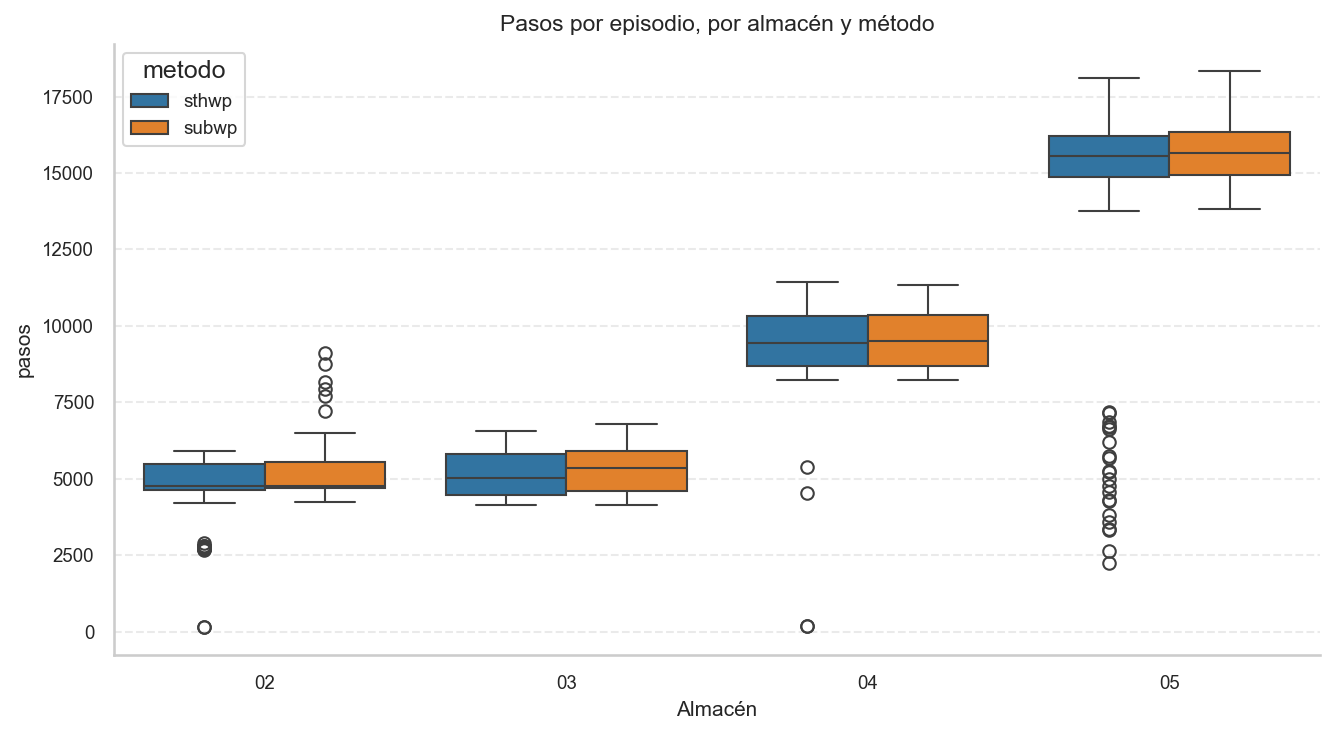

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df1, x="warehouse_id", y="pasos", hue="metodo", order=WH_ORDEN, ax=ax)
ax.set_title("Pasos por episodio, por almacén y método")
ax.set_xlabel("Almacén")
plt.tight_layout()
guardar(fig, "06a_pasos_por_almacen")
plt.show()


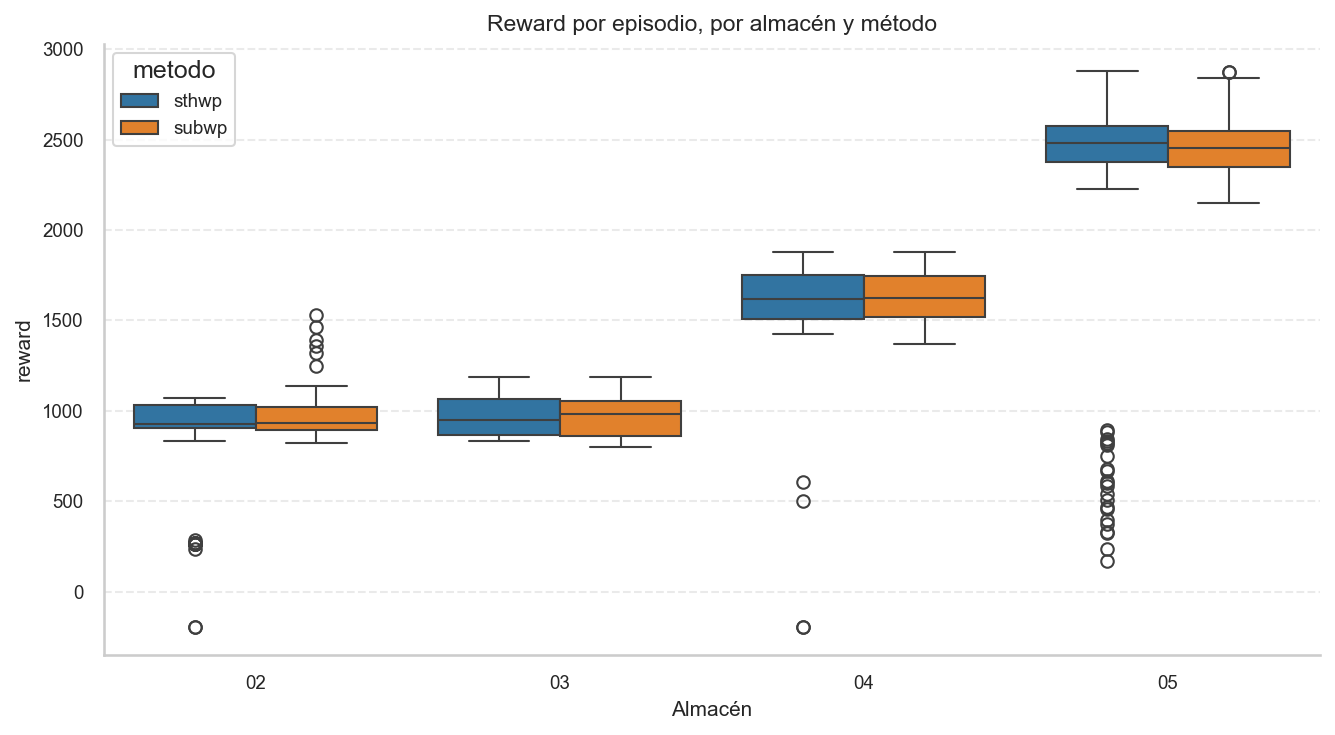

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df1, x="warehouse_id", y="reward", hue="metodo", order=WH_ORDEN, ax=ax)
ax.set_title("Reward por episodio, por almacén y método")
ax.set_xlabel("Almacén")
plt.tight_layout()
guardar(fig, "06b_reward_por_almacen")
plt.show()


/var/folders/f5/mfsbgdz157x618_ct5hj62g00000gn/T/ipykernel_19293/459653226.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x="resultado", y="pasos", order=[r for r in RESULTADO_ORDEN if r in df1["resultado"].unique()], ax=ax,


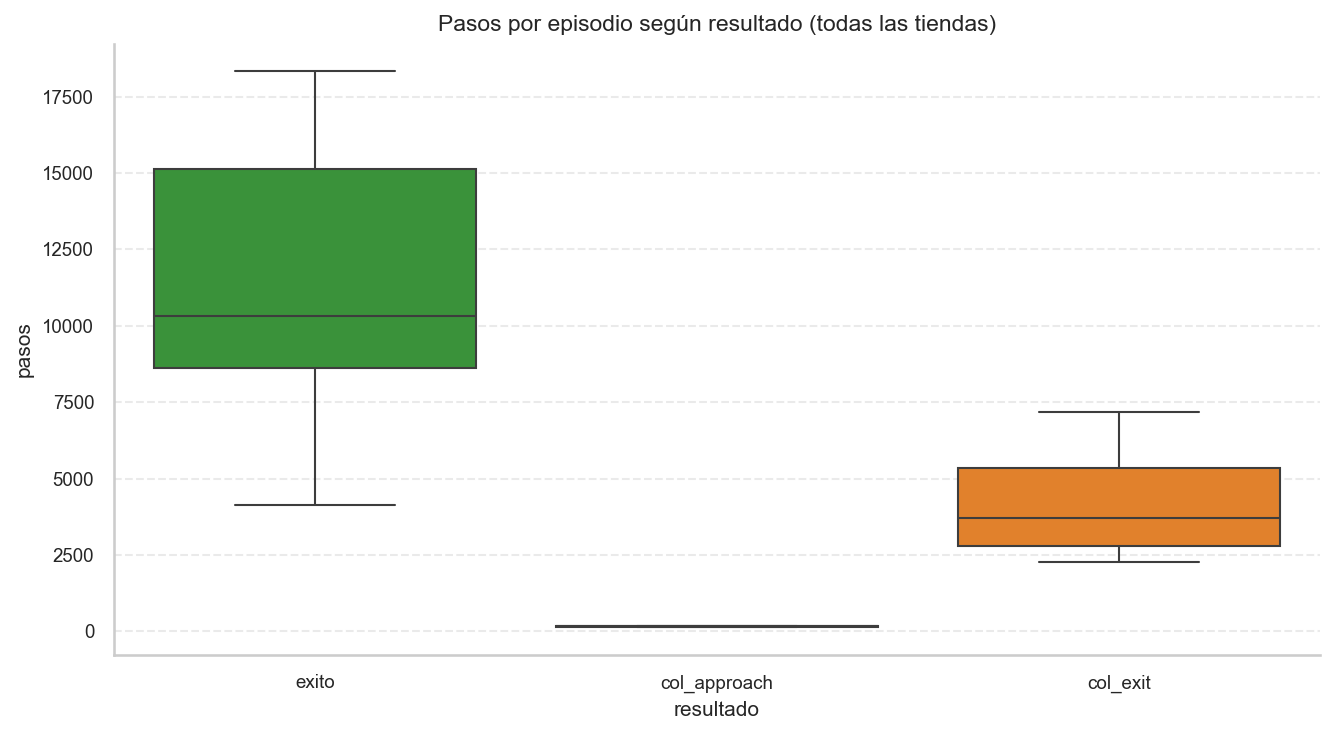

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df1, x="resultado", y="pasos", order=[r for r in RESULTADO_ORDEN if r in df1["resultado"].unique()], ax=ax,
            palette=RESULTADO_COLOR)
ax.set_title("Pasos por episodio según resultado (todas las tiendas)")
plt.tight_layout()
guardar(fig, "07_pasos_por_resultado")
plt.show()


### Análisis de outliers
¿Los valores atípicos de pasos/reward son episodios exitosos que tardaron mucho, o colisiones concretas? Se marca como outlier todo episodio fuera de 1.5×IQR respecto a su grupo almacén+método (la misma regla que usan los bigotes del boxplot), por separado para `pasos` y para `reward`.

In [19]:
def marcar_outliers_iqr(df, col, by=("warehouse_id", "metodo")):
    def _outlier(s):
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        return (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
    return df.groupby(list(by), observed=True)[col].transform(_outlier)

df1["outlier_pasos"] = marcar_outliers_iqr(df1, "pasos")
df1["outlier_reward"] = marcar_outliers_iqr(df1, "reward")
df1["outlier_alguno"] = df1["outlier_pasos"] | df1["outlier_reward"]

n_por_resultado = df1.groupby("resultado", observed=False).size()
tabla_outliers = pd.DataFrame({
    "n_episodios": n_por_resultado,
    "outliers_pasos": df1[df1["outlier_pasos"]].groupby("resultado", observed=False).size(),
    "outliers_reward": df1[df1["outlier_reward"]].groupby("resultado", observed=False).size(),
}).fillna(0).astype({"outliers_pasos": int, "outliers_reward": int})
tabla_outliers["%_outliers_pasos"] = (tabla_outliers["outliers_pasos"] / tabla_outliers["n_episodios"] * 100).round(1)
tabla_outliers["%_outliers_reward"] = (tabla_outliers["outliers_reward"] / tabla_outliers["n_episodios"] * 100).round(1)
n_outliers_total = df1["outlier_alguno"].sum()
print(f"Total episodios marcados como outlier (pasos y/o reward): {n_outliers_total} / {len(df1)}")
tabla_outliers


Total episodios marcados como outlier (pasos y/o reward): 50 / 8136


,n_episodios,outliers_pasos,outliers_reward,%_outliers_pasos,%_outliers_reward
resultado,,,,,
exito,8094,6,8,0.1,0.1
col_approach,4,4,4,100.0,100.0
col_exit,38,38,38,100.0,100.0
col_return,0,0,0,NaN,NaN
truncado,0,0,0,NaN,NaN


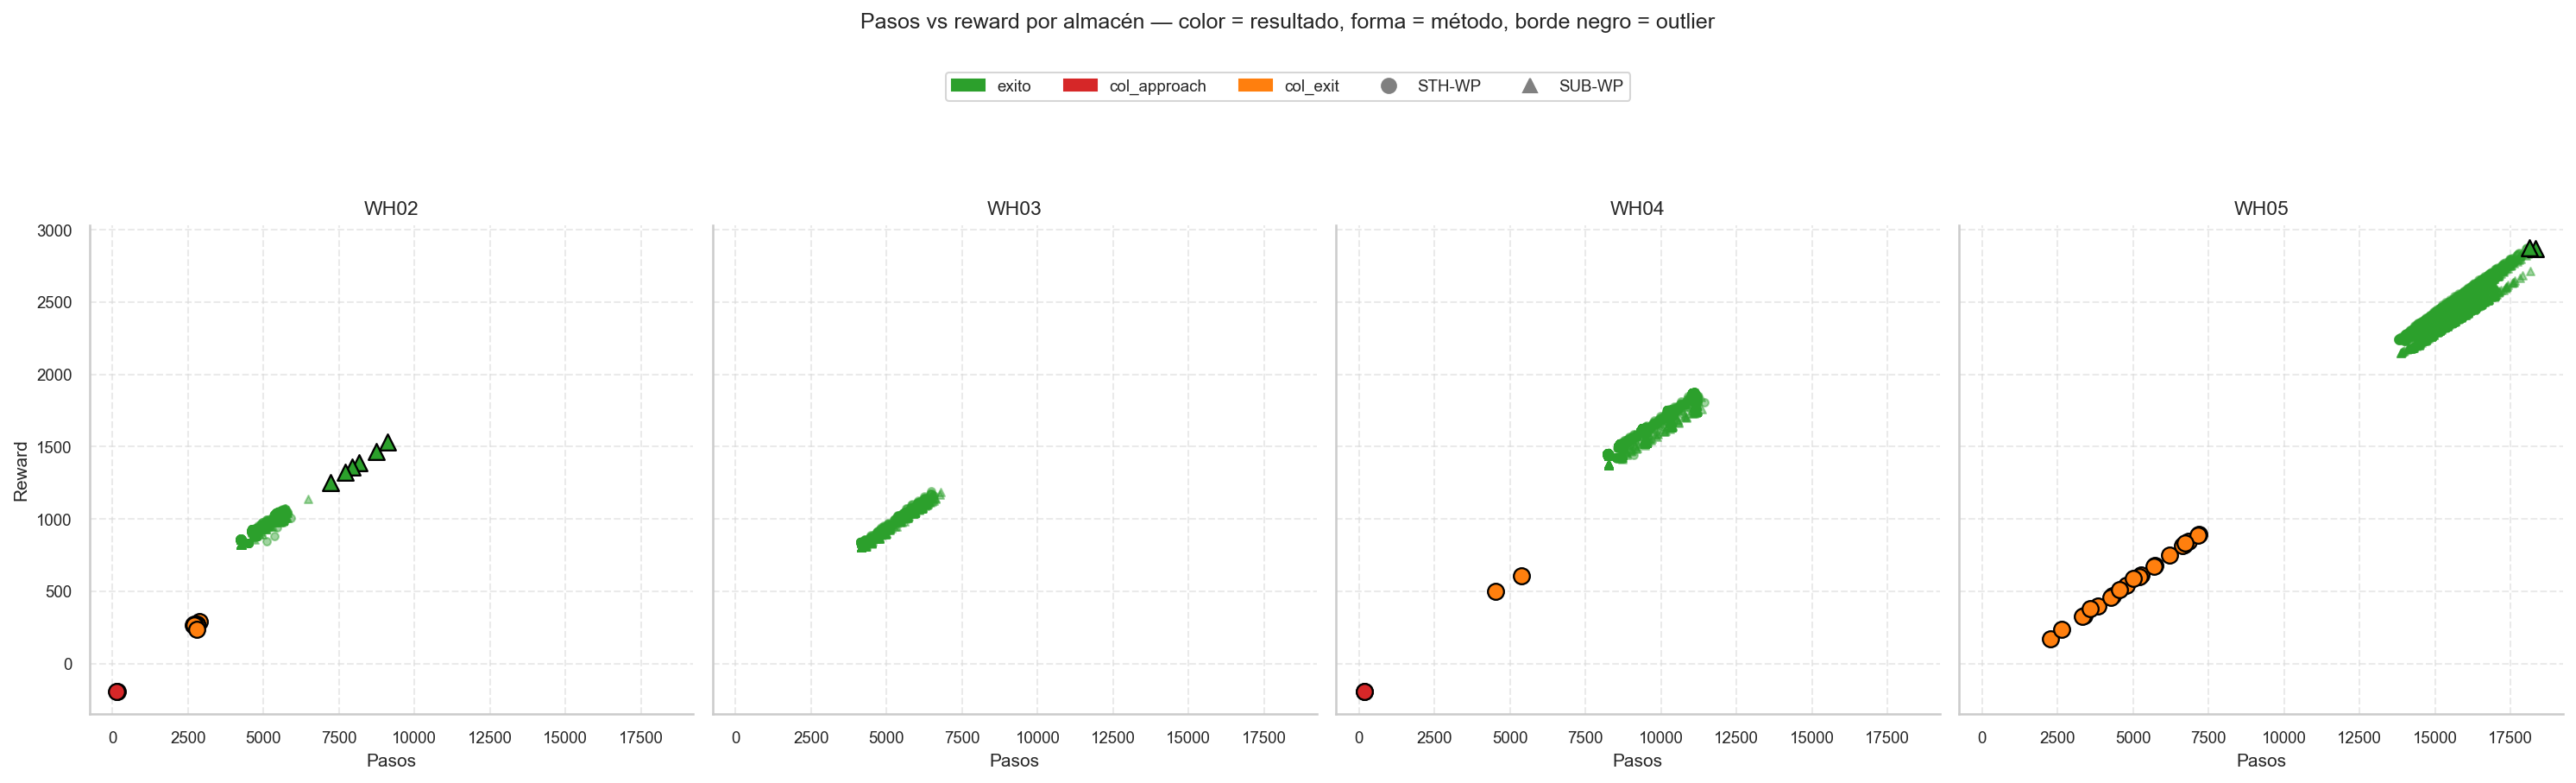

In [20]:
marker_metodo = {"sthwp": "o", "subwp": "^"}

fig, axes = plt.subplots(1, len(WH_ORDEN), figsize=(5 * len(WH_ORDEN), 5), sharex=True, sharey=True)
for ax, wh in zip(axes, WH_ORDEN):
    sub_wh = df1[df1["warehouse_id"] == wh]
    for metodo in METODO_ORDEN:
        sub_m = sub_wh[sub_wh["metodo"] == metodo]
        for resultado in RESULTADO_ORDEN:
            sub = sub_m[sub_m["resultado"] == resultado]
            if sub.empty:
                continue
            normales = sub[~sub["outlier_alguno"]]
            atipicos = sub[sub["outlier_alguno"]]
            ax.scatter(normales["pasos"], normales["reward"], color=RESULTADO_COLOR[resultado],
                       marker=marker_metodo[metodo], s=18, alpha=0.45)
            if not atipicos.empty:
                ax.scatter(atipicos["pasos"], atipicos["reward"], facecolor=RESULTADO_COLOR[resultado],
                           edgecolor="black", linewidth=1.1, marker=marker_metodo[metodo], s=80, zorder=5)
    ax.set_title(f"WH{wh}")
    ax.set_xlabel("Pasos")
axes[0].set_ylabel("Reward")

leyenda_color = [mpatches.Patch(color=RESULTADO_COLOR[r], label=r)
                 for r in RESULTADO_ORDEN if r in df1["resultado"].unique()]
leyenda_marker = [plt.Line2D([0], [0], marker=marker_metodo[m], color="gray", linestyle="",
                              markersize=8, label=METODO_LABEL[m]) for m in METODO_ORDEN]
fig.legend(handles=leyenda_color + leyenda_marker, loc="upper center",
           ncol=len(leyenda_color) + len(leyenda_marker), bbox_to_anchor=(0.5, 1.12))
fig.suptitle("Pasos vs reward por almacén — color = resultado, forma = método, borde negro = outlier", y=1.2)
plt.tight_layout()
guardar(fig, "07b_outliers_pasos_vs_reward")
plt.show()


## 7. Goals con fallos
Goals que registraron al menos un fallo en algún método/seed (de un total de 1.356 goals por método/seed).

In [21]:
fallos_por_goal = (
    df1[~df1["exito_bool"]]
    .groupby(["warehouse_id", "goal_id"], observed=True)
    .agg(n_fallos=("resultado", "size"),
         metodos=("metodo", lambda s: sorted(set(s))),
         resultados=("resultado", lambda s: sorted(set(s))))
    .sort_values("n_fallos", ascending=False)
)
print(f"Nº de goals con al menos un fallo: {len(fallos_por_goal)}")
fallos_por_goal.head(30)


Nº de goals con al menos un fallo: 42


n_fallos  metodos      resultados
warehouse_id goal_id                                    
02           goal_001         1  [sthwp]  [col_approach]
05           goal_325         1  [sthwp]      [col_exit]
             goal_133         1  [sthwp]      [col_exit]
             goal_155         1  [sthwp]      [col_exit]
             goal_181         1  [sthwp]      [col_exit]
             goal_183         1  [sthwp]      [col_exit]
             goal_229         1  [sthwp]      [col_exit]
             goal_251         1  [sthwp]      [col_exit]
             goal_277         1  [sthwp]      [col_exit]
             goal_279         1  [sthwp]      [col_exit]
             goal_327         1  [sthwp]      [col_exit]
02           goal_002         1  [sthwp]  [col_approach]
05           goal_347         1  [sthwp]      [col_exit]
             goal_373         1  [sthwp]      [col_exit]
             goal_395         1  [sthwp]      [col_exit]
             goal_421         1  [sthwp]      [col_exit]
             goal_423         1  [sthwp]      [col_exit]
             goal_445         1  [sthwp]      [col_exit]
             goal_469         1  [sthwp]      [col_exit]
             goal_471         1  [sthwp]      [col_exit]
             goal_105         1  [sthwp]      [col_exit]
             goal_087         1  [sthwp]      [col_exit]
             goal_085         1  [sthwp]      [col_exit]
04           goal_581         1  [sthwp]      [col_exit]
02           goal_021         1  [sthwp]      [col_exit]
             goal_023         1  [sthwp]      [col_exit]
             goal_026         1  [sthwp]      [col_exit]
             goal_027         1  [sthwp]      [col_exit]
             goal_029         1  [sthwp]      [col_exit]
             goal_031         1  [sthwp]      [col_exit]

## 8. Mapa espacial de fallos por almacén
Posición de cada goal en el almacén (rojo = tuvo algún fallo en algún método/seed, verde = 100% éxito), junto con las zonas de espera/descarga.

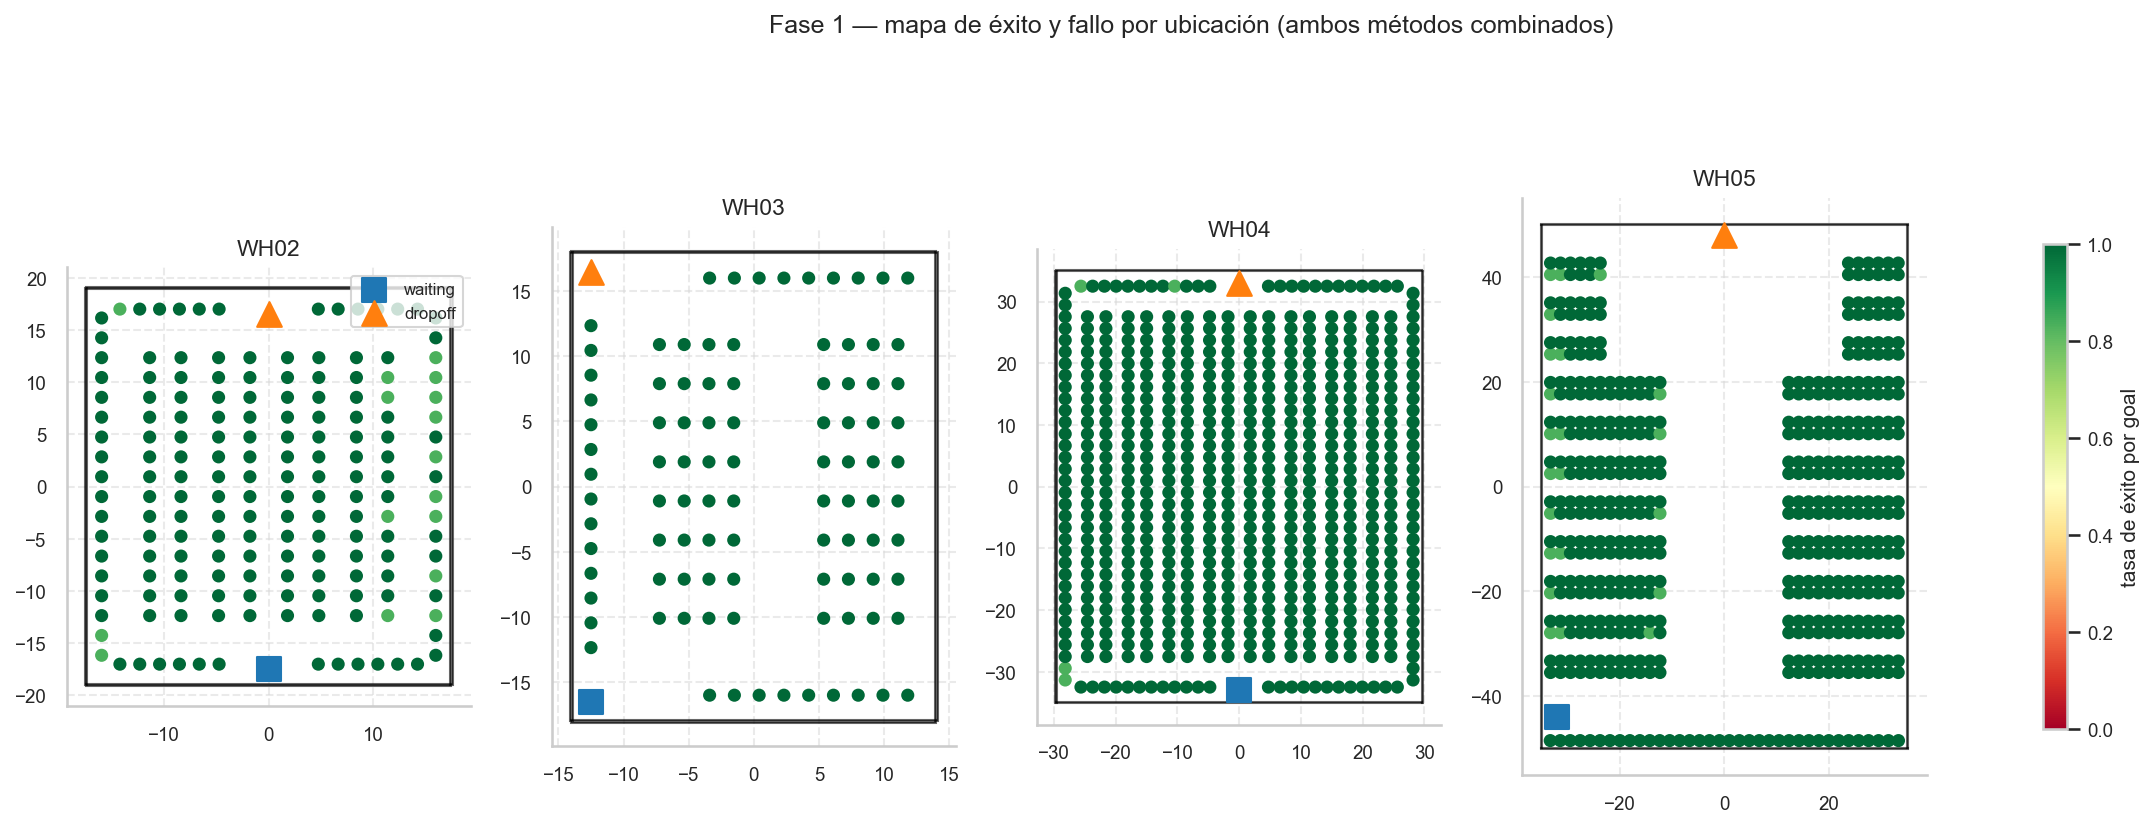

In [22]:
def cargar_mapa(wh):
    with open(STHWP_DIR / f"warehouse_map{wh}.json") as f:
        return json.load(f)

def plot_almacen(ax, wh, df_wh):
    mapa = cargar_mapa(wh)
    for wall in mapa["walls"]:
        rect = mpatches.Rectangle(
            (wall["x"] - wall["w"] / 2, wall["y"] - wall["h"] / 2), wall["w"], wall["h"],
            color="black", alpha=0.6)
        ax.add_patch(rect)
    zonas = mapa["zones"]
    ax.scatter(*zonas["waiting"].values(), marker="s", s=140, color="#1f77b4", label="waiting", zorder=5)
    ax.scatter(*zonas["dropoff"].values(), marker="^", s=140, color="#ff7f0e", label="dropoff", zorder=5)

    fallo_por_goal = df_wh.groupby("goal_id", observed=True)["exito_bool"].mean()
    coords = {s["goal_id"]: (s["goal_x"], s["goal_y"]) for s in mapa["shelves"]}
    xs, ys, colores = [], [], []
    for gid, tasa in fallo_por_goal.items():
        if gid not in coords:
            continue
        x, y = coords[gid]
        xs.append(x); ys.append(y)
        colores.append(tasa)
    sc = ax.scatter(xs, ys, c=colores, cmap="RdYlGn", vmin=0, vmax=1, s=28, zorder=4)
    ax.set_title(f"WH{wh}")
    ax.set_aspect("equal")
    return sc

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for ax, wh in zip(axes, WH_ORDEN):
    sub = df1[df1["warehouse_id"] == wh]
    sc = plot_almacen(ax, wh, sub)
axes[0].legend(loc="upper right", fontsize=8)
cbar = fig.colorbar(sc, ax=axes, shrink=0.7, label="tasa de éxito por goal")
fig.suptitle("Fase 1 — mapa de éxito y fallo por ubicación (ambos métodos combinados)", y=1.02)
guardar(fig, "08_mapa_espacial_fallos")
plt.show()


### Mapa por seed y método
El mapa combinado de arriba promedia las 3 seeds y los 2 métodos, lo que puede diluir un patrón que solo aparece en una combinación concreta. Aquí se desglosa cada almacén en una rejilla de 6 paneles (2 métodos × 3 seeds), en verde/rojo puro (éxito/fallo) porque con 1 episodio por goal/seed/método el resultado ya es binario — no hace falta promediar nada.

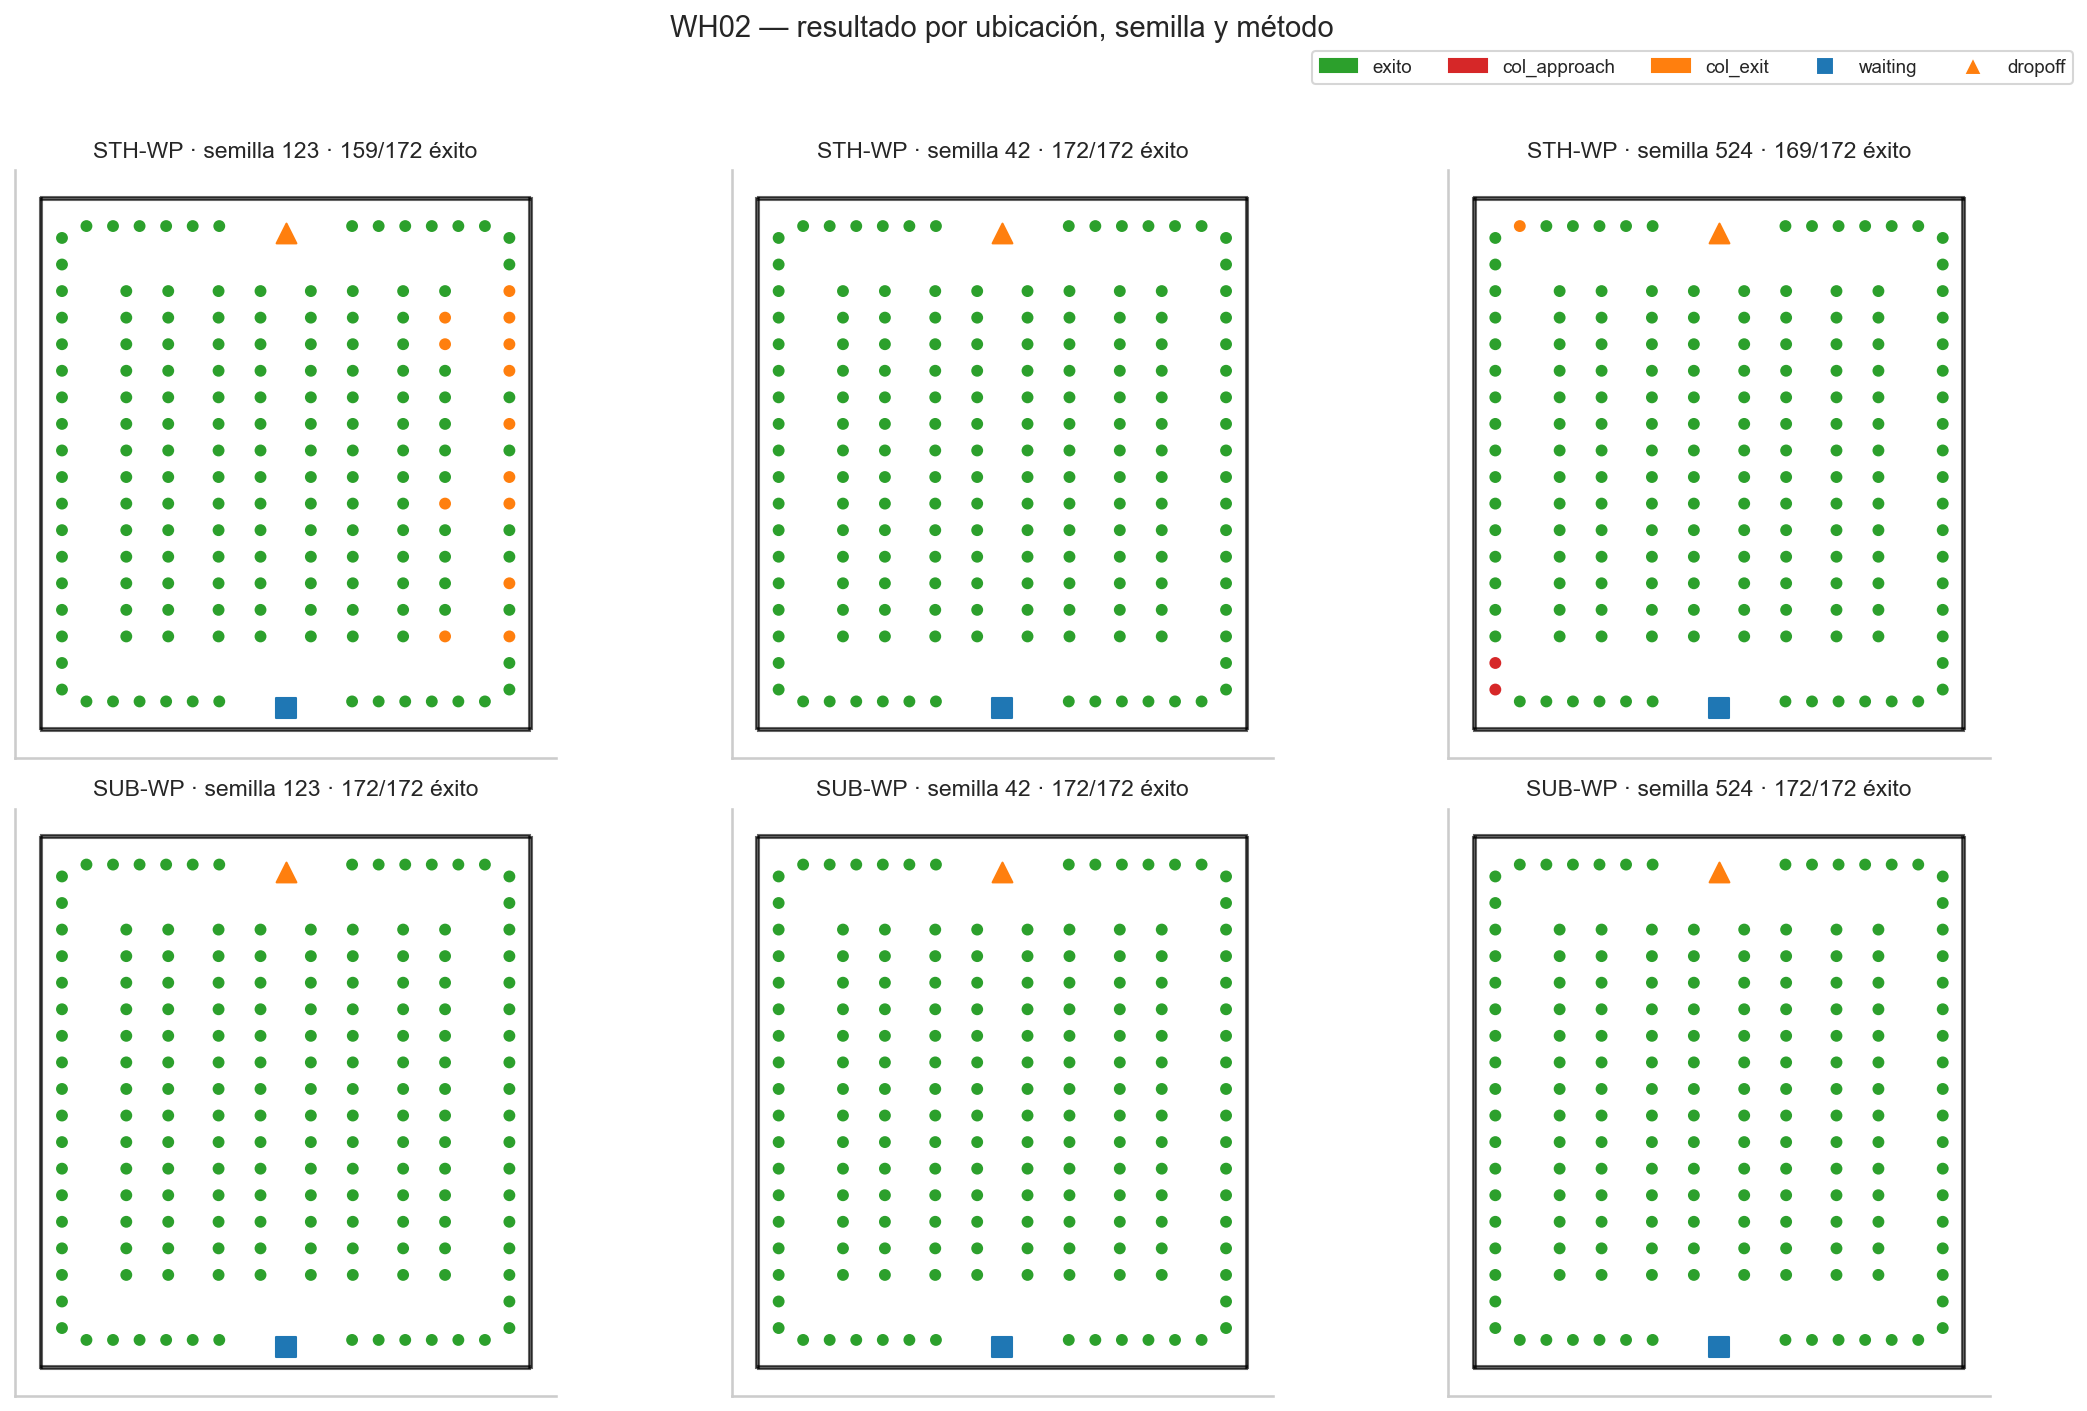

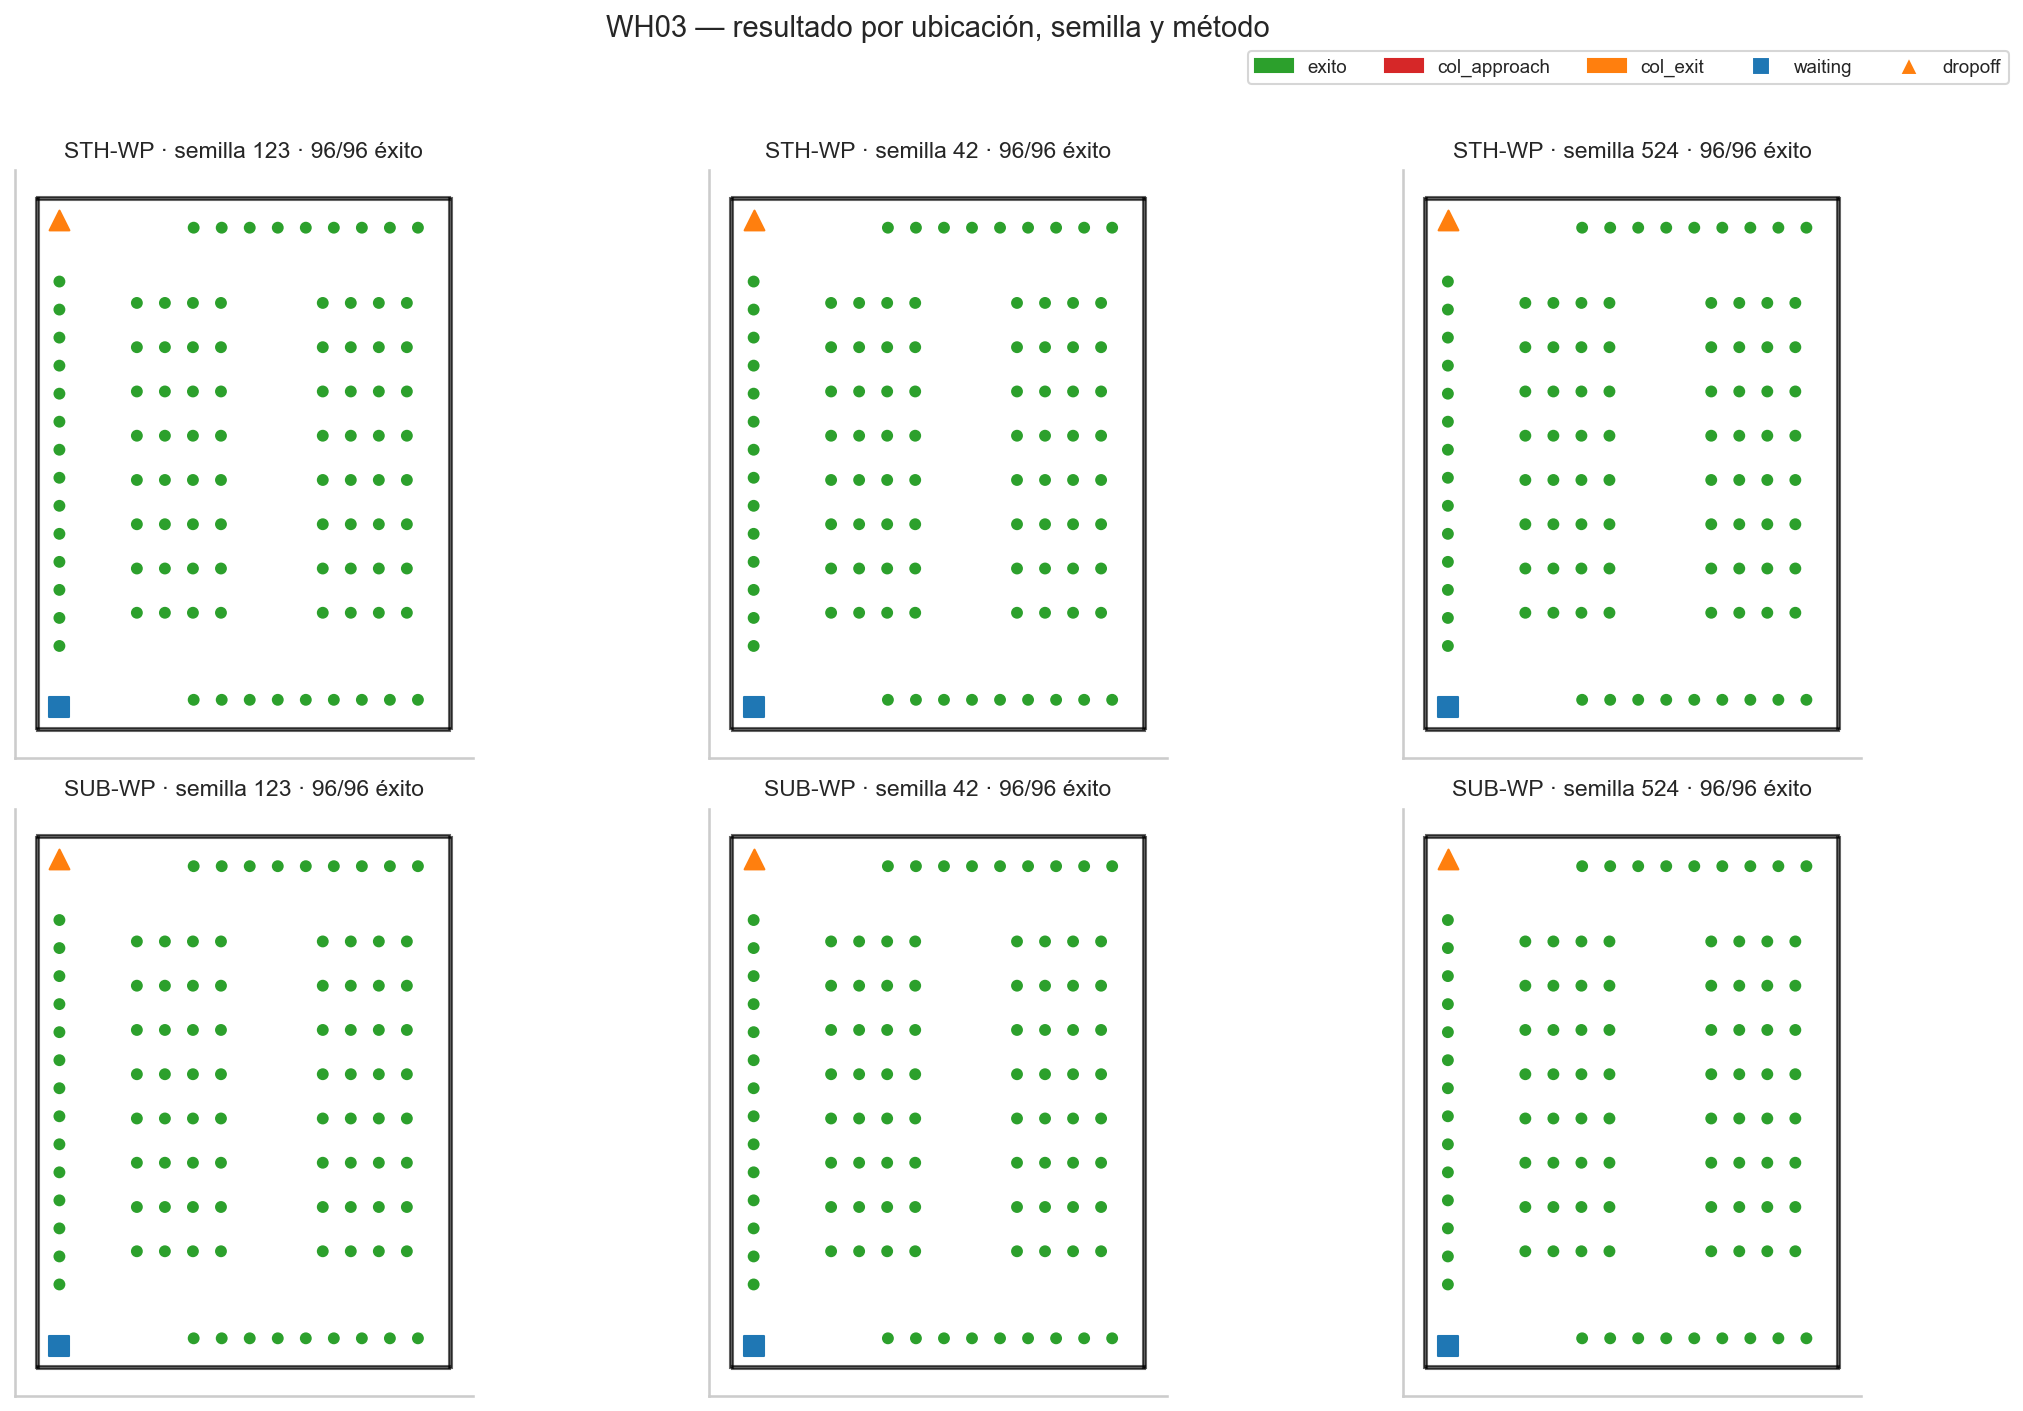

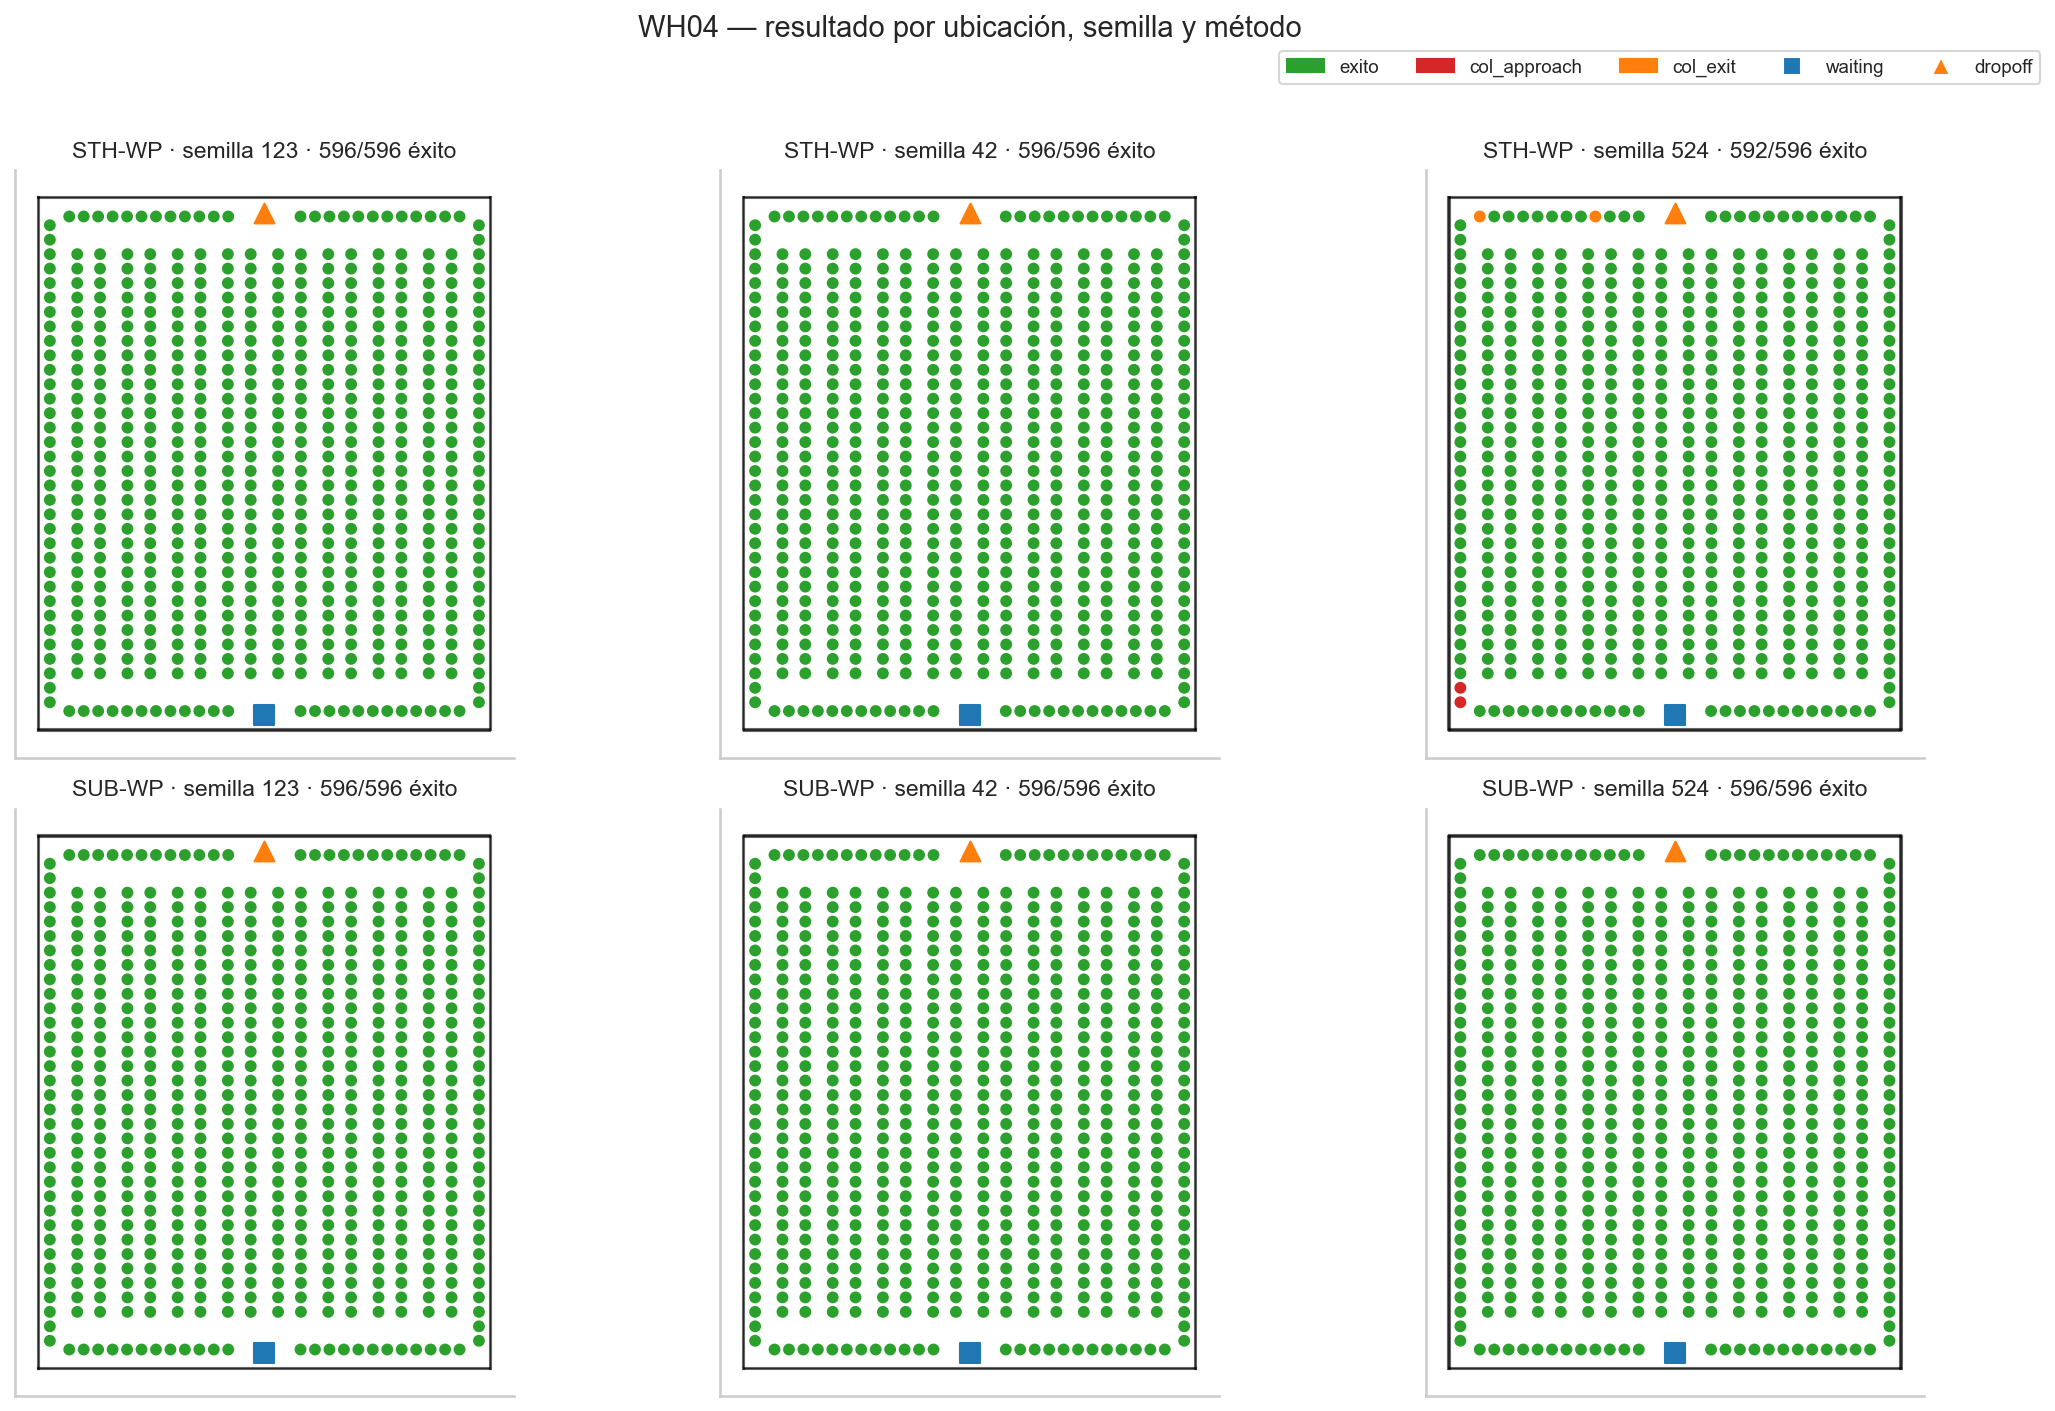

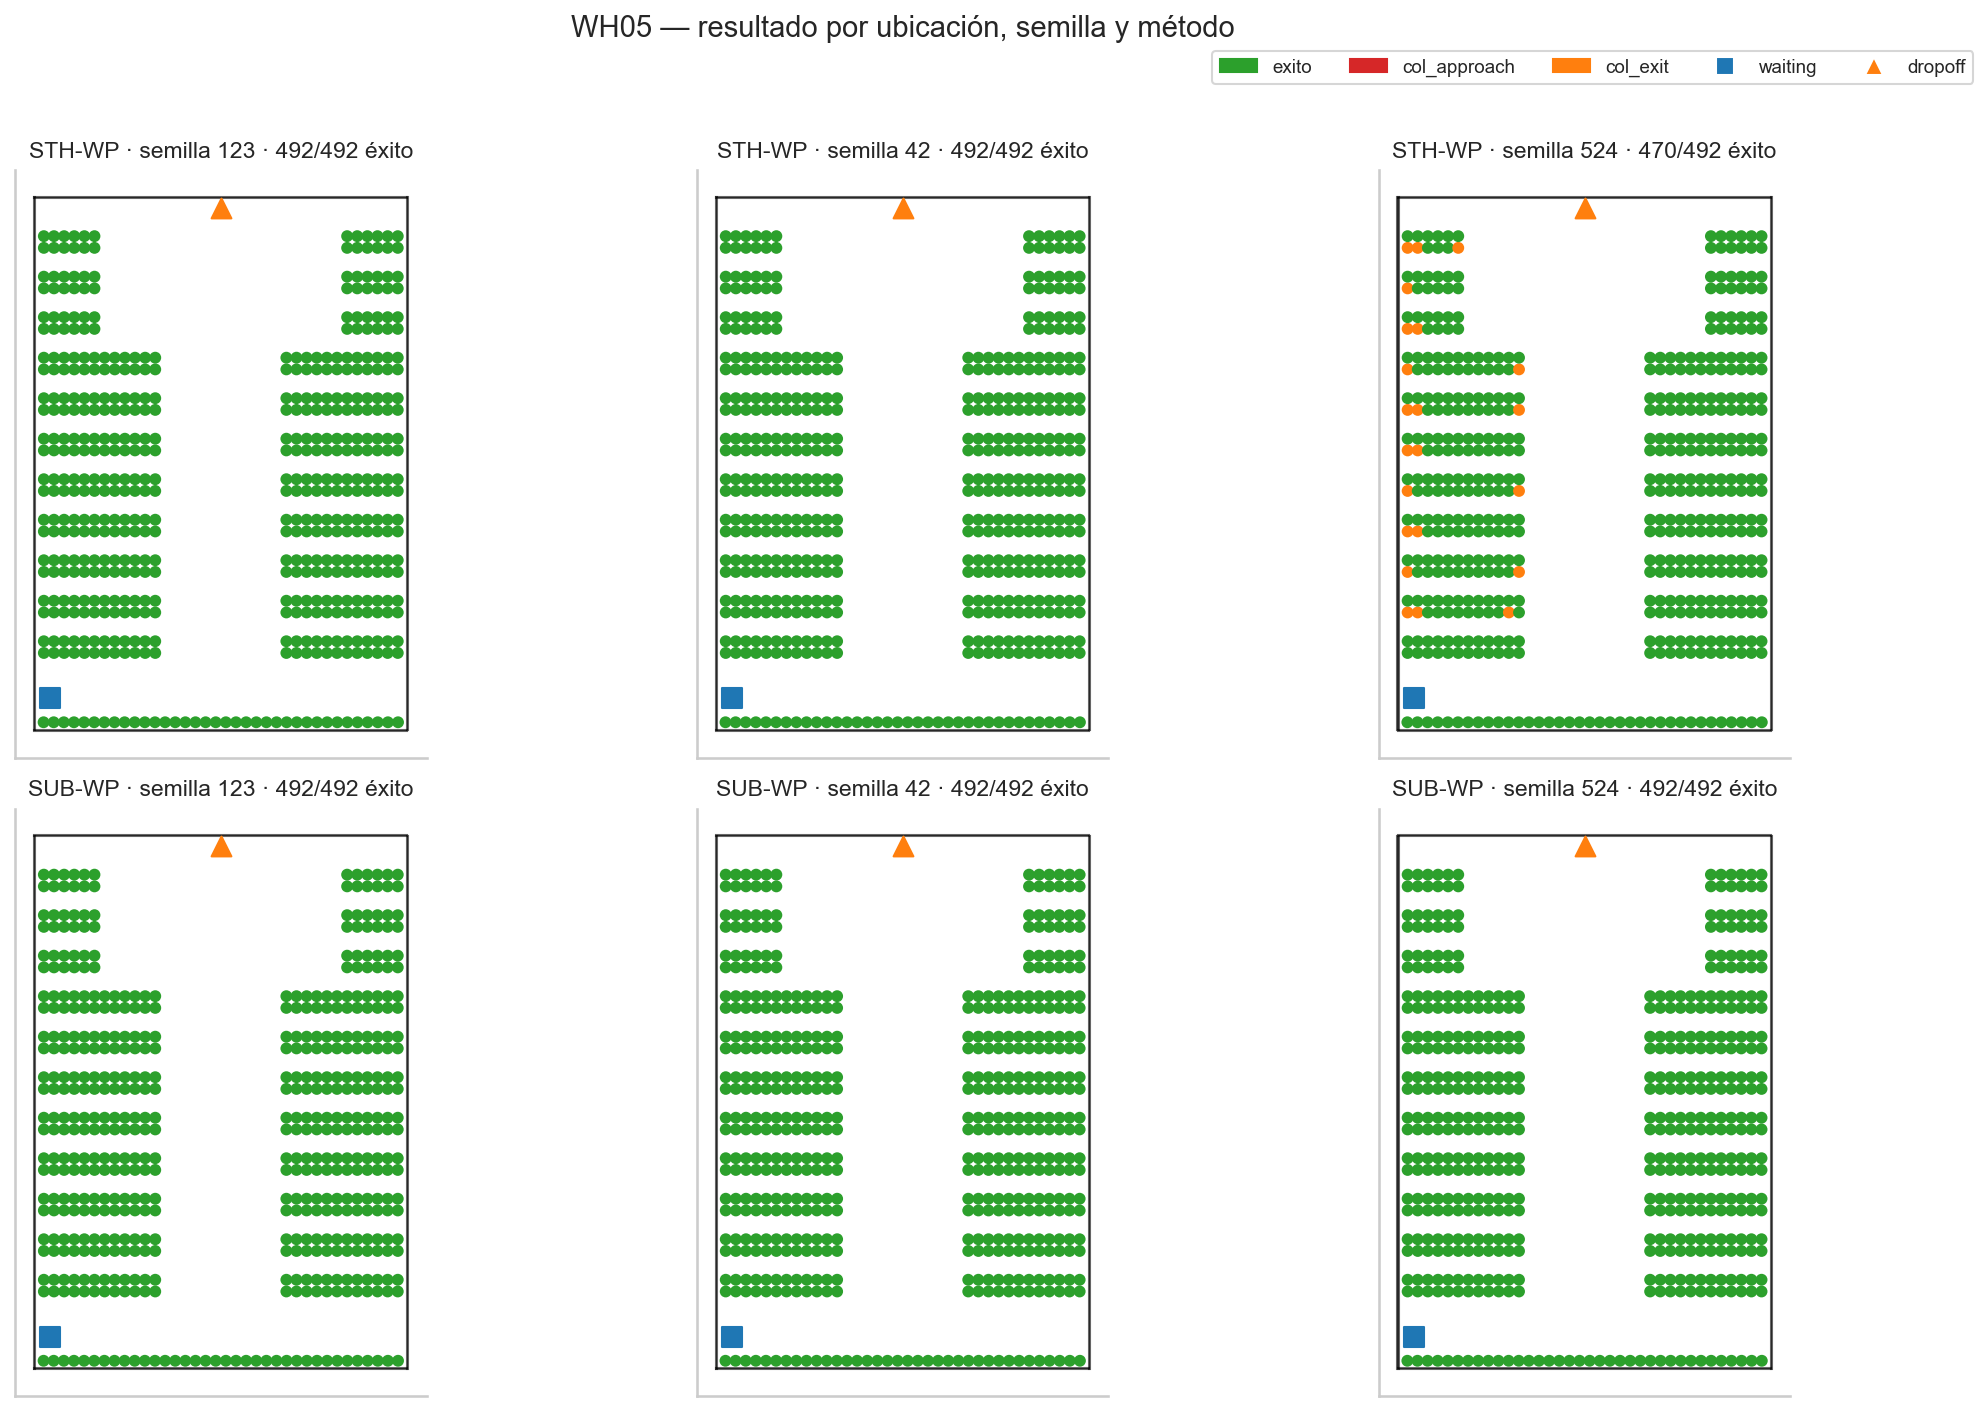

In [23]:
def plot_almacen_binario(ax, wh, df_wh_1):
    mapa = cargar_mapa(wh)
    for wall in mapa["walls"]:
        rect = mpatches.Rectangle(
            (wall["x"] - wall["w"] / 2, wall["y"] - wall["h"] / 2), wall["w"], wall["h"],
            color="black", alpha=0.6)
        ax.add_patch(rect)
    zonas = mapa["zones"]
    ax.scatter(*zonas["waiting"].values(), marker="s", s=90, color="#1f77b4", zorder=5)
    ax.scatter(*zonas["dropoff"].values(), marker="^", s=90, color="#ff7f0e", zorder=5)

    coords = {s["goal_id"]: (s["goal_x"], s["goal_y"]) for s in mapa["shelves"]}
    xs, ys, colores = [], [], []
    for _, row in df_wh_1.iterrows():
        gid = row["goal_id"]
        if gid not in coords:
            continue
        x, y = coords[gid]
        xs.append(x); ys.append(y)
        colores.append(RESULTADO_COLOR[row["resultado"]])
    ax.scatter(xs, ys, c=colores, s=22, zorder=4)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


leyenda = [
    mpatches.Patch(color=RESULTADO_COLOR[r], label=r) for r in RESULTADO_ORDEN if r in df1["resultado"].unique()
] + [
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="#1f77b4", markersize=9, label="waiting"),
    plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="#ff7f0e", markersize=9, label="dropoff"),
]

for wh in WH_ORDEN:
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for i, metodo in enumerate(METODO_ORDEN):
        for j, seed in enumerate(sorted(df1["seed"].unique())):
            ax = axes[i, j]
            sub = df1[(df1["warehouse_id"] == wh) & (df1["metodo"] == metodo) & (df1["seed"] == seed)]
            plot_almacen_binario(ax, wh, sub)
            ax.set_title(f"{METODO_LABEL[metodo]} · semilla {seed} · {int(sub['exito_bool'].sum())}/{len(sub)} éxito")
    fig.legend(handles=leyenda, loc="upper right", ncol=len(leyenda), bbox_to_anchor=(0.98, 1.02))
    fig.suptitle(f"WH{wh} — resultado por ubicación, semilla y método", y=1.04, fontsize=14)
    plt.tight_layout()
    guardar(fig, f"09_mapa_seed_metodo_WH{wh}")
    plt.show()


## 9. Conclusiones — Fase 1

- **SUB-WP generaliza igual o mejor que STH-WP** en almacenes no vistos (~100% vs ~99%), **invirtiendo** el orden observado en el entrenamiento (WH01: STH-WP 88.75% > SUB-WP 82.36%, con peatón).
- El *generalization gap* respecto al baseline sin peatón de WH01 (100%/100%) es pequeño para ambos métodos.
- Los fallos residuales se concentran en tramos concretos — revisar la sección 5 y el mapa espacial para identificar patrones geométricos (esquinas, pasillos estrechos) asociados a los goals más problemáticos.
